In [4]:
import sys
!{sys.executable} -m pip install -U fastbook -q

In [7]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

## 1. Get Data from MNIST

Retrieve 6 and 7s' data from MNIST

In [10]:
path = untar_data(URLs.MNIST)
Path.BASE_PATH = path
path.ls()

<div><progress max="15683414" value="15687680"></progress> 100.03% [15687680/15683414 00:01&lt;00:00]</div>

[Path('training'), Path('testing')]

In [12]:
(path/'training').ls()

[Path('training/3'), Path('training/2'), Path('training/4'), Path('training/0'), Path('training/9'), Path('training/8'), Path('training/5'), Path('training/1'), Path('training/7'), Path('training/6')]

In [14]:
sixes = (path/'training'/'6').ls().sorted()
sevens = (path/'training'/'7').ls().sorted()

Test viewing one of the loaded images, using *Python Imaging Library(PIL)*, the most widely used Py package for opening, manipulating, and viewing images

In [19]:
#hide
im6_path=sixes[0]
im6=Image.open(im6_path)
im6

In [18]:
#hide
im6_t = tensor(im6)
df = pd.DataFrame(im6_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,10,0,0,0,0,0,0,0,109,229,253,253,201,14,0,0
1,0,0,113,0,0,0,0,0,0,49,228,253,253,245,84,0,0,0
2,0,0,0,0,0,0,0,0,35,227,253,253,243,86,0,0,0,0
3,0,0,0,0,0,0,0,26,146,253,253,242,87,0,0,0,0,0
4,0,0,0,0,0,0,8,187,253,253,253,157,0,0,0,0,0,0
5,0,0,0,0,0,8,145,253,253,253,182,18,0,0,0,0,0,0
6,0,0,0,0,0,38,253,253,253,240,48,0,0,0,0,0,0,0
7,0,0,0,0,0,128,253,253,212,51,0,0,0,0,0,0,0,0
8,0,0,0,0,24,231,253,240,84,0,0,0,0,0,0,0,0,0
9,0,0,0,0,128,253,253,107,0,0,0,22,75,178,199,199,56,0


In [20]:
six_tensors = [tensor(Image.open(o)) for o in sixes]
seven_tensors = [tensor(Image.open(o)) for o in sevens]
len(six_tensors), len(sixes)

(5918, 5918)

<Axes: >

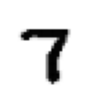

In [21]:
#hide
show_image(seven_tensors[0])

<Axes: >

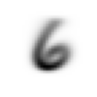

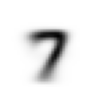

In [24]:
stacked_sixes = torch.stack(six_tensors).float()/255
stacked_sevens = torch.stack(seven_tensors).float()/255
mean6 = stacked_sixes.mean(0)
show_image(mean6)

mean7 = stacked_sevens.mean(0)
show_image(mean7)

In [25]:
train_x = torch.cat([stacked_sixes, stacked_sevens]).view(-1, 28*28)

Put images into input (`x`) and output (`y`) tensors

In [26]:
train_y = tensor([1]*len(sixes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape, train_y.shape

(torch.Size([12183, 784]), torch.Size([12183, 1]))

In [27]:
ds = list(zip(train_x, train_y))
x,y = ds[0]
x.shape, y

(torch.Size([784]), tensor([1]))

Do same thing for validation dataset

In [30]:
valid_6_tens = torch.stack([tensor(Image.open(o))
                           for o in (path/'testing'/'6').ls()])
valid_7_tens = torch.stack([tensor(Image.open(o))
                           for o in (path/'testing'/'7').ls()])
valid_6_tens = valid_6_tens.float()/255
valid_7_tens = valid_7_tens.float()/255

valid_x = torch.cat([valid_6_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_6_tens))
valid_ds = list(zip(valid_x, valid_y))

Initialize initially random weights for each pixel

In [31]:
def init_params(size, std = 1.0):
    return (torch.randn(size)*std).requires_grad_()

In [41]:
weights = init_params((28*28, 1))
bias = init_params(1)

In [42]:
(train_x[0]*weights.T).sum() + bias

tensor([8.5998], grad_fn=<AddBackward0>)

In [43]:
def linear1(xb):
    return xb@weights + bias # @ does matrix multiplication

In [49]:
dl = DataLoader (ds, batch_size = 256)
xb, yb = first(dl)
xb.shape, yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

In [51]:
valid_dl = DataLoader(valid_ds, batch_size = 256)

In [52]:
batch = train_x[:4]
batch.shape

torch.Size([4, 784])

## 2. Train on One Epoch

In [79]:
def train_epoch(model, lr, params):
    for xb, yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [80]:
(preds>0.0).float() == train_y[:4]

tensor([[ True],
        [ True],
        [False],
        [ True]])

In [89]:
def sigmoid(x):
    return 1/(1 + torch.exp(-x))
    
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [76]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb),yb) for xb, yb in valid_dl]
    return round(torch.stack(accs).mean().item(),4)

In [82]:
batch_accuracy(linear1(batch), train_y[:4])

tensor(0.7500)

In [83]:
validate_epoch(linear1)

0.9559

In [84]:
lr = 1.
params = weights, bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.9905

In [85]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end = ' ')

0.9882 0.5806 0.8498 0.9395 0.9624 0.9657 0.9745 0.9758 0.9801 0.9811 0.9843 0.9843 0.9853 0.9866 0.9876 0.9876 0.9889 0.9889 0.9899 0.9899 

## 3. Create Optimizer

In [86]:
linear_model = nn.Linear(28*28, 1)
w, b = linear_model.parameters()
w.shape, b.shape

(torch.Size([1, 784]), torch.Size([1]))

In [87]:
class BasicOptim:
    def __init__ (self, params, lr):
        self.params, self.lr = list(params), lr

    def step(self, *args, **kwargs):
        for p in self.params:
            p.data -= p.grad.data*self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params:
            p.grad = None

In [88]:
opt = BasicOptim(linear_model.parameters(),lr)

In [91]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

def calc_grad(xb,yb,model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

def train_epoch(model):
    for xb, yb in dl:
        calc_grad(xb,yb,model)
        opt.step()
        opt.zero_grad()

Function for validating epoch

In [92]:
validate_epoch(linear_model)

0.0332

In [93]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [94]:
train_model(linear_model, 20)

0.859 0.8949 0.9595 0.9791 0.9853 0.9882 0.9902 0.9915 0.9925 0.9925 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9967 0.9967 

Same thing as above, but using `SGD` class by fastai library:

In [95]:
linear_model = nn.Linear(28*28, 1)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.8782 0.8789 0.9582 0.9791 0.9853 0.9892 0.9915 0.9915 0.9925 0.9944 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9954 0.9967 

In [109]:
class DsetList(list):
    def new_empty(self):
        return self.__class__([])

dset = DsetList(zip(train_x, train_y))
valid_dset = DsetList(zip(valid_x,valid_y))
dl = DataLoader(dset, batch_size = 256, shuffle = True)
valid_dl = DataLoader(valid_dset, batch_size = 256)

dls = DataLoaders(dl, valid_dl)
learn = Learner(dls, nn.Linear(28*28, 1), opt_func = SGD,
               loss_func = mnist_loss, metrics = batch_accuracy)
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.031601,0.015958,0.994781,00:00
1,0.016833,0.011120,0.996868,00:00
2,0.011388,0.011055,0.996868,00:00
3,0.008464,0.009394,0.996868,00:00
4,0.006947,0.008905,0.996868,00:00
5,0.006109,0.008224,0.996868,00:00
6,0.005540,0.008294,0.996868,00:00
7,0.005067,0.007428,0.996868,00:00
8,0.004678,0.006594,0.996868,00:00
9,0.004373,0.006738,0.996868,00:00


## 4. Export Model

In [111]:
learn.export()